In [19]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.metrics import f1_score, precision_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import joblib

In [20]:
df = pd.read_csv("./data/explored_data.csv", index_col=0)
df.head()

,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type,booking_changes,deposit_type,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,hotel
0,0,365,July,27,1,0,0,2,0.0,0,...,C,3,No Deposit,0.0,0,Transient,0.0,0,0,Resort
1,0,737,July,27,1,0,0,2,0.0,0,...,C,4,No Deposit,0.0,0,Transient,0.0,0,0,Resort
2,0,365,July,27,1,0,1,1,0.0,0,...,C,0,No Deposit,0.0,0,Transient,75.0,0,0,Resort
3,0,365,July,27,1,0,1,1,0.0,0,...,A,0,No Deposit,0.0,0,Transient,75.0,0,0,Resort
4,0,365,July,27,1,0,2,2,0.0,0,...,A,0,No Deposit,0.0,0,Transient,98.0,0,1,Resort


In [21]:
df.shape

(87120, 28)

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 87120 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   is_canceled                     87120 non-null  int64  
 1   lead_time                       87120 non-null  int64  
 2   arrival_date_month              87120 non-null  str    
 3   arrival_date_week_number        87120 non-null  int64  
 4   arrival_date_day_of_month       87120 non-null  int64  
 5   stays_in_weekend_nights         87120 non-null  int64  
 6   stays_in_week_nights            87120 non-null  int64  
 7   adults                          87120 non-null  int64  
 8   children                        87116 non-null  float64
 9   babies                          87120 non-null  int64  
 10  meal                            87120 non-null  str    
 11  country                         87120 non-null  str    
 12  market_segment                  87120 non-null 

In [23]:
df.describe()

,is_canceled,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000,87116.000000,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000,87120.000000
mean,0.272750,365.449231,26.837052,15.814761,1.005326,2.625390,1.875849,0.138884,0.010836,0.039187,0.030234,0.184573,0.272245,11.019789,0.731910,106.366950,0.084493,0.699931
std,0.445376,7.356553,13.674536,8.835061,1.031576,2.051726,0.626837,0.456255,0.113676,0.194042,0.369375,1.734604,0.727994,54.044990,9.866169,55.047746,0.281939,0.832233
min,0.000000,365.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,365.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,365.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,365.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


The most promising features are lead_time, deposite_type, market segment, adr, previous_cancellation, arrival_date_day_of_month, stays_in_week_nights, hotel, costomer_type and others that are more than 5% in the corr plot in the EDA shows significant percentage in the EDA recently having huge influence on the cancellation rate

Having these useful features and using them as my features for the ML modelling would aid bias correction since the model would not predict blindly. But, looking at the features now, they contain NAN which would flag Value error (X contain null), the solution is to create another dataframe that contain only the features selected and the target, then completely drop the nan as that would clear the error. and also cause the model to predict without any bias in it accuracy and other metrics results

In [24]:
df.isna().sum().sort_values(ascending=False)

children                          4
is_canceled                       0
arrival_date_month                0
lead_time                         0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_week_nights              0
stays_in_weekend_nights           0
adults                            0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
hotel                       

In [25]:
# Defining the columns that falls above 5% in the corr as the new features to avoid bias in the model prediction

features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
    'adults', 'children', 'is_repeated_guest', 'previous_cancellations', 
    'previous_bookings_not_canceled', 'booking_changes', 'company', 
    'adr', 'required_car_parking_spaces', 'total_of_special_requests'
]

# dropping the nan in the features columns and in the target columns
chosen_col = list(features) + ["is_canceled"]
cleaned_columns = df.loc[:, chosen_col].dropna().copy()

In [26]:
cleaned_columns.isna().sum().sum()

np.int64(0)

### Defining the target and the features

In [27]:
# defining the feature to being the columns that are higher than 5% in the correation
X = cleaned_columns[features] # the feature
y = cleaned_columns["is_canceled"] # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print (f"The training size: {len(X_train)} The training shape: {X_train.shape}")
print (f"The testing size: {len(X_test)} The texting shape: {X_test.shape}")

The training size: 69692 The training shape: (69692, 13)
The testing size: 17424 The texting shape: (17424, 13)


The stays_in_weekend_nights and the stays_in_week_nights columns would be concaatinated into one column in the future when Logistic regression model or suppor vector (XGBoost or SVM models) are introduced inorder to avoid redundancy. 

### Feature Scaling

In [28]:
scaler= StandardScaler()

train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.transform(X_test)

### Baseline model

In [29]:
l_model = LogisticRegression()

l_model_train = l_model.fit(train_scaled, y_train)
l_model_pred = l_model.predict(test_scaled)

print (f"Prediction: {accuracy_score(y_test, l_model_pred):.2f}")

Prediction: 0.75


plotting a confusion matric would display the different numbers of the positive, negative, false positive and false negative

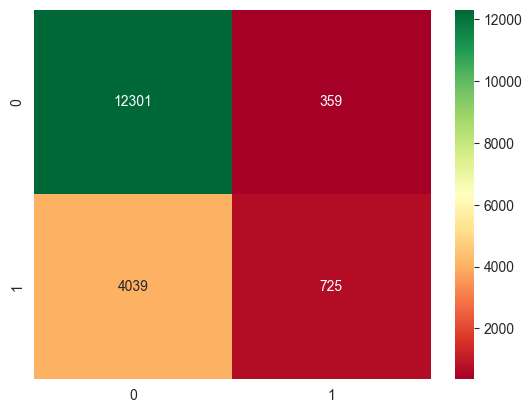

<Figure size 800x600 with 0 Axes>

              precision    recall  f1-score   support

           0       0.75      0.97      0.85     12660
           1       0.67      0.15      0.25      4764

    accuracy                           0.75     17424
   macro avg       0.71      0.56      0.55     17424
weighted avg       0.73      0.75      0.68     17424



In [30]:
cm = confusion_matrix(y_test, l_model_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn")
plt.figure(figsize=(8, 6))
plt.show()

print(classification_report(y_test, l_model_pred))

according to this report, the recall for cancelation occurence is 15% which would cause the model to predict only those guests that are likely to stay even if they would eventually leave. So, introducing RandoForestClassifier model and causing the 'class_weight' to be balanced would make the model understand that cancelationrate is also as important as not cancel. 

In [31]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

rf_train = rf_model.fit(train_scaled, y_train)
rf_pred = rf_model.predict(test_scaled)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79     12660
           1       0.47      0.51      0.49      4764

    accuracy                           0.71     17424
   macro avg       0.64      0.65      0.64     17424
weighted avg       0.72      0.71      0.71     17424



introducing probability threshold that would cause the model to predict even when there is 35% chance for cancelation. Not only relying on the 51% from the Randon Forest Classifier model's predictions 

In [32]:
rf_prob = rf_model.predict_proba(test_scaled)[:, 1]

rf_prob_pred = (rf_prob >= 0.3).astype(int)

report = classification_report(y_test, rf_prob_pred)

print (report)

              precision    recall  f1-score   support

           0       0.83      0.65      0.73     12660
           1       0.41      0.64      0.50      4764

    accuracy                           0.65     17424
   macro avg       0.62      0.65      0.61     17424
weighted avg       0.71      0.65      0.67     17424



According to the report above, the result for cancelation and not cancelation are almost the same and this neutralizes the model's performance into balanced report without guessing but giving the metric report as accurate as possible 

Now introducing feature importance to know the features influencing the model's report most

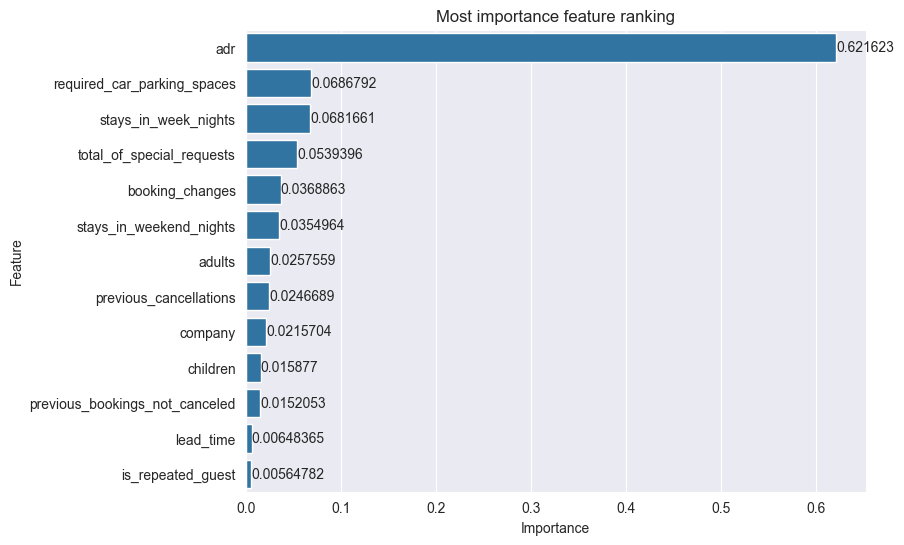

In [33]:
f_importance = rf_model.feature_importances_
f_importance_df = pd.DataFrame({"Feature": features, "Importance": f_importance})
f_importance_df = f_importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x="Importance", y="Feature", data=f_importance_df)

for container in ax.containers:
    total = (f"{p.get_height():.1f}" for p in container)
    ax.bar_label(container, label=total)

plt.title("Most importance feature ranking")
plt.show()

According to the feature importance plot above, the model's prediction denoted **62%** adr importance in all the features. This moeans that price has the altimate influence on the cancelation rate as the other features are likely subordinates arround price which is the **Dominant feature**. According to the plot and the dataset, guests/bookers are **price sensitive** and this means they have the tendency of canceling if they discorver **alternative** that is more affordable in terms of price.

is_canceled
0    102.005725
1    117.995537
Name: adr, dtype: float64


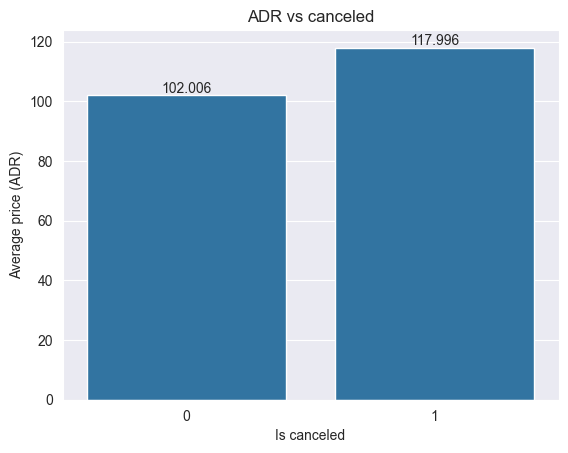

In [34]:
matrix = (df.groupby("is_canceled")["adr"].mean())

print(matrix)

ax = sns.barplot(x=matrix.index, y=matrix.values)

for container in ax.containers: 
    total = (f"{h.get_height():.1f}" for h in container)
    ax.bar_label(container, label = total)
    
plt.title("ADR vs canceled")
plt.ylabel("Average price (ADR)")
plt.xlabel("Is canceled")
plt.show()

According to the report above, there is risk of cancelation when the ADR rise above 103.
My suggestion, there should be a means of getting in touch with the booker when their booking ADR is greater than 103 or a targeted discount should be offer to reduce the desire or urge to cancel

### Saving the model for deployment